### Identificação MIMO ARMAX com MOGWO

Reproduz o modelo ARMAX (eq. 15) do artigo. O MOCS (melhor da Tabela
2) não tem código disponível — ver
`docs/changes/2026-09-25-reproduzir-mogwo.md`. Para o MOGWO, usamos os
72 parâmetros do melhor modelo publicados na Tabela 3 do artigo
diretamente (coluna MOGWO), em vez de reotimizar do zero. Dados
gerados por `notebooks/processing/01_mimo_dataset_from_papper.ipynb`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio

DATA_RAW = Path("../../data/raw")
DATA_EXTERNAL = Path("../../data/external")
DATA_PROCESSED = Path("../../data/processed")

TABELA3_PATH = DATA_EXTERNAL / "tabela3_parametros_armax_papper.csv"
MOGWO_MAT_PATH = (
    DATA_RAW
    / "WRSO and NSWRSO_draft_all"
    / "Multi_objective_for_MIMO_systems"
    / "imprime_gráficos"
    / "MOGWO.mat"
)

INPUT_COLS = ["freq_b1", "freq_b2", "freq_b3", "vazao_entrada"]
OUTPUT_COLS = ["vazao_distribuicao", "nivel_res", "pressao"]
N_PARAMS = 72
N_LAGS = 3
N_OUTPUTS = 3

### Dados

`u1..u4` = frequências das bombas + vazão de entrada; `y1..y3` = vazão
de distribuição, nível e pressão.

In [2]:
train_df = pd.read_parquet(
    DATA_PROCESSED / "mimo_dataset_sample_from_papper_train.parquet"
)
test_df = pd.read_parquet(
    DATA_PROCESSED / "mimo_dataset_sample_from_papper_test.parquet"
)

U_train = train_df[INPUT_COLS].to_numpy().T
Y_train = train_df[OUTPUT_COLS].to_numpy().T
U_test = test_df[INPUT_COLS].to_numpy().T
Y_test = test_df[OUTPUT_COLS].to_numpy().T

print("treino:", U_train.shape, Y_train.shape)
print("teste:", U_test.shape, Y_test.shape)

treino: (4, 601) (3, 601)
teste: (4, 501) (3, 501)


### Modelo ARMAX (equação 15)

Porte vetorizado de `fun_objetivo.m`: 24 parâmetros por saída (self +
outras 2 saídas + 4 entradas, todos com 3 lags, mais correção sobre o
erro), 72 no total. Predição one-step usando só valores medidos.

In [3]:
def _lag(x: np.ndarray, lag: int) -> np.ndarray:
    """Lag a (tam,) or (tam, pop) array by `lag` steps, zero-filled."""
    shifted = np.zeros_like(x)
    shifted[lag:] = x[:-lag]
    return shifted


def armax_predict(x: np.ndarray, u: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Predição one-step ARMAX (equação 15) para uma população.

    Como no MATLAB original, as 3 primeiras predições são iguais ao
    valor medido (sem histórico para os lags), então o erro delas é zero.

    Args:
        x: parâmetros, shape (72, pop).
        u: entradas medidas, shape (4, tam).
        y: saídas medidas, shape (3, tam).

    Returns:
        Predições, shape (3, tam, pop).
    """
    tam = y.shape[1]
    pop = x.shape[1]

    y_lags = [[_lag(y[i], lag) for lag in (1, 2, 3)] for i in range(3)]
    u_lags = [[_lag(u[i], lag) for lag in (1, 2, 3)] for i in range(4)]

    y_pred = np.zeros((3, tam, pop))
    for out in range(3):
        base = out * 24
        a_self = x[base : base + 3]
        others = [o for o in range(3) if o != out]
        a_other1 = x[base + 3 : base + 6]
        a_other2 = x[base + 6 : base + 9]
        b_u = x[base + 9 : base + 21].reshape(4, 3, pop)
        c_e = x[base + 21 : base + 24]

        pred = np.zeros((tam, pop))
        for lag_idx, lag in enumerate((1, 2, 3)):
            pred -= np.outer(y_lags[out][lag_idx], a_self[lag_idx])
            pred -= np.outer(y_lags[others[0]][lag_idx], a_other1[lag_idx])
            pred -= np.outer(y_lags[others[1]][lag_idx], a_other2[lag_idx])
            for inp in range(4):
                pred += np.outer(u_lags[inp][lag_idx], b_u[inp, lag_idx])
        pred[:3] = y[out, :3, None]

        e = y[out][:, None] - pred
        e_lags = [_lag(e, lag) for lag in (1, 2, 3)]
        correction = sum(e_lags[k] * c_e[k] for k in range(3))

        y_pred[out] = pred + correction

    return y_pred


def armax_objective(x: np.ndarray, u: np.ndarray, y: np.ndarray) -> np.ndarray:
    """MSE por saída (3 objetivos) para cada indivíduo da população.

    Args:
        x: parâmetros, shape (72, pop).
        u: entradas medidas, shape (4, tam).
        y: saídas medidas, shape (3, tam).

    Returns:
        MSE por saída, shape (3, pop).
    """
    tam = y.shape[1]
    y_pred = armax_predict(x, u, y)
    error = y[:, :, None] - y_pred
    return np.sum(error**2, axis=1) / tam

### Verificação: parâmetros nulos → predição zero a partir da 4ª amostra

In [4]:
x_zero = np.zeros((N_PARAMS, 1))
mse_zero = armax_objective(x_zero, U_train, Y_train)
tam_train = Y_train.shape[1]
mse_expected = np.sum(Y_train[:, 3:] ** 2, axis=1, keepdims=True) / tam_train

print(mse_zero.ravel())
print(mse_expected.ravel())
assert np.allclose(mse_zero, mse_expected)

[5423.14232717    5.78799621  520.22542101]
[5423.14232717    5.78799621  520.22542101]


### Verificação cruzada com o MATLAB

`MOGWO.mat` guarda as soluções (`PARETO_SET`) e o custo que o MATLAB
calculou para cada uma (`PARETO_FRONT`). Nossa `armax_objective` deve
reproduzir esse custo.

In [5]:
mat = sio.loadmat(MOGWO_MAT_PATH)
pareto_set = mat["PARETO_SET"].reshape(N_PARAMS, -1)
pareto_front = mat["PARETO_FRONT"].reshape(N_OUTPUTS, -1)

filled = np.any(pareto_set != 0, axis=0)  # descarta slots vazios (zero-fill)
pareto_set, pareto_front = pareto_set[:, filled], pareto_front[:, filled]

cost_python = armax_objective(pareto_set, U_train, Y_train)
rel_err = np.abs(cost_python - pareto_front) / pareto_front

print("soluções comparadas:", pareto_set.shape[1])
print("erro relativo máximo (y1, y2, y3):", rel_err.max(axis=1))
assert np.allclose(cost_python, pareto_front, rtol=1e-9)

soluções comparadas: 1500
erro relativo máximo (y1, y2, y3): [2.95701023e-15 3.81500336e-15 2.88910855e-15]


### MOGWO — implementação de referência (opcional)

Porte de `MOGWO.m` para caso se queira reotimizar do zero (não é
executado no fluxo principal — ver "Carregar parâmetros do melhor
modelo (Tabela 3)" abaixo, que usa os parâmetros publicados).

In [6]:
rng = np.random.default_rng(seed=42)


def dominates(costs_a: np.ndarray, costs_b: np.ndarray) -> bool:
    """True if solution `a` Pareto-dominates `b` (minimization)."""
    return bool(np.all(costs_a <= costs_b) and np.any(costs_a < costs_b))


def determine_dominated(costs: np.ndarray) -> np.ndarray:
    """Flag dominated individuals, shape (n_obj, n).

    Mirrors DetermineDomination.m: O(n^2) pairwise comparison.
    """
    n = costs.shape[1]
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(i):
            if dominated[j]:
                continue
            if dominates(costs[:, i], costs[:, j]):
                dominated[j] = True
            elif dominates(costs[:, j], costs[:, i]):
                dominated[i] = True
                break
    return dominated


def create_hypercubes(
    costs: np.ndarray, n_grid: int, alpha: float
) -> list[np.ndarray]:
    """Grid boundaries per objective (n_grid+1 edges -> n_grid cells)."""
    grids = []
    for j in range(costs.shape[0]):
        c_min, c_max = costs[j].min(), costs[j].max()
        margin = alpha * (c_max - c_min)
        edges = np.linspace(c_min - margin, c_max + margin, n_grid - 1)
        grids.append(np.concatenate(([-np.inf], edges, [np.inf])))
    return grids


def grid_index(costs: np.ndarray, grids: list[np.ndarray]) -> np.ndarray:
    """Flat hypercube index per individual, shape (n,)."""
    n_obj, n = costs.shape
    sub = np.zeros((n_obj, n), dtype=int)
    for j in range(n_obj):
        sub[j] = np.searchsorted(grids[j][1:], costs[j], side="left")
    n_grid = len(grids[0]) - 1
    flat = np.zeros(n, dtype=int)
    for j in range(n_obj):
        flat = flat * n_grid + sub[j]
    return flat


def roulette_wheel(p: np.ndarray) -> int:
    r = rng.random()
    return int(np.searchsorted(np.cumsum(p), r, side="left"))


def select_leader(
    archive_idx: np.ndarray, cell_of: np.ndarray, beta: float
) -> int:
    """Select one archive member index, favouring less-crowded cells."""
    cells, counts = np.unique(cell_of[archive_idx], return_counts=True)
    p = counts.astype(float) ** (-beta)
    p /= p.sum()
    chosen_cell = cells[roulette_wheel(p)]
    members = archive_idx[cell_of[archive_idx] == chosen_cell]
    return int(rng.choice(members))


def delete_from_archive(
    archive_idx: np.ndarray, cell_of: np.ndarray, extra: int, gamma: float
) -> np.ndarray:
    """Drop `extra` members from the most crowded cells (roulette)."""
    archive_idx = archive_idx.copy()
    for _ in range(extra):
        cells, counts = np.unique(cell_of[archive_idx], return_counts=True)
        p = counts.astype(float) ** gamma
        p /= p.sum()
        chosen_cell = cells[roulette_wheel(p)]
        members = archive_idx[cell_of[archive_idx] == chosen_cell]
        drop = rng.choice(members)
        archive_idx = archive_idx[archive_idx != drop]
    return archive_idx

In [7]:
def mogwo(
    u: np.ndarray,
    y: np.ndarray,
    n_wolves: int,
    max_iter: int,
    n_params: int,
    archive_size: int = 30,
    n_grid: int = 10,
    grid_alpha: float = 0.1,
    beta: float = 4.0,
    gamma: float = 2.0,
) -> tuple[np.ndarray, np.ndarray]:
    """Multi-Objective Grey Wolf Optimizer (porte de MOGWO.m).

    Fiel ao MATLAB em dois pontos que afetam a convergência: Beta e
    Alpha são sorteados entre os líderes ainda não usados, e o
    coeficiente `A` de Beta e Alpha é escalar (o de Delta é vetor). Também
    como no MATLAB, as posições não são recortadas em `[lb, ub]` após a
    inicialização.

    Args:
        u, y: dados de entrada/saída medidos.
        n_wolves: tamanho da população (search_agents no artigo).
        max_iter: número máximo de gerações.
        n_params: dimensão do problema (72 para o ARMAX do artigo).
        archive_size: tamanho máximo do arquivo de soluções.
        n_grid: número de células da grade por objetivo.
        grid_alpha: fator de inflação da grade.
        beta: pressão de seleção do líder.
        gamma: pressão de seleção para exclusão do arquivo.

    Returns:
        (archive_x, archive_f): posições e custos das soluções no
        arquivo final, shapes (n_params, k) e (3, k).
    """
    lb, ub = -1.0, 1.0
    positions = rng.uniform(lb, ub, size=(n_params, n_wolves))
    costs = armax_objective(positions, u, y)

    dominated = determine_dominated(costs)
    archive_x = positions[:, ~dominated]
    archive_f = costs[:, ~dominated]

    grids = create_hypercubes(archive_f, n_grid, grid_alpha)
    cell_of = grid_index(archive_f, grids)

    for it in range(max_iter):
        a = 2 - it * (2 / max_iter)
        archive_idx = np.arange(archive_x.shape[1])

        for i in range(n_wolves):
            delta = select_leader(archive_idx, cell_of, beta)
            beta_w = select_leader(archive_idx, cell_of, beta)
            alpha_w = select_leader(archive_idx, cell_of, beta)
            if archive_idx.size > 1:
                rest = archive_idx[archive_idx != delta]
                beta_w = select_leader(rest, cell_of, beta)
            if archive_idx.size > 2:
                rest2 = rest[rest != beta_w]
                alpha_w = select_leader(rest2, cell_of, beta)

            new_pos = np.zeros(n_params)
            for k, leader_idx in enumerate((delta, beta_w, alpha_w)):
                leader = archive_x[:, leader_idx]
                c = 2 * rng.random(n_params)
                d = np.abs(c * leader - positions[:, i])
                if k == 0:
                    coef_a = 2 * a * rng.random(n_params) - a
                else:
                    coef_a = 2 * a * rng.random() - a
                new_pos += leader - coef_a * d
            positions[:, i] = new_pos / 3

        costs = armax_objective(positions, u, y)
        dominated = determine_dominated(costs)
        new_nondominated_x = positions[:, ~dominated]
        new_nondominated_f = costs[:, ~dominated]

        archive_x = np.concatenate([archive_x, new_nondominated_x], axis=1)
        archive_f = np.concatenate([archive_f, new_nondominated_f], axis=1)
        dominated = determine_dominated(archive_f)
        archive_x = archive_x[:, ~dominated]
        archive_f = archive_f[:, ~dominated]

        grids = create_hypercubes(archive_f, n_grid, grid_alpha)
        cell_of = grid_index(archive_f, grids)

        if archive_x.shape[1] > archive_size:
            extra = archive_x.shape[1] - archive_size
            keep_idx = delete_from_archive(
                np.arange(archive_x.shape[1]), cell_of, extra, gamma
            )
            archive_x = archive_x[:, keep_idx]
            archive_f = archive_f[:, keep_idx]
            grids = create_hypercubes(archive_f, n_grid, grid_alpha)
            cell_of = grid_index(archive_f, grids)

    return archive_x, archive_f

### Carregar parâmetros do melhor modelo (Tabela 3 do artigo)

A Tabela 3 publica os 72 parâmetros do melhor modelo de cada
metaheurística. `data/external/tabela3_parametros_armax_papper.csv`
foi transcrito do artigo, coluna `MOGWO`. A ordem das linhas já segue
a mesma convenção posicional de `armax_predict` (self, saída 2, saída
3, u1..u4, erro — cada bloco com os 3 lags), então nenhum remapeamento
de índice é necessário — verificado célula a célula contra a equação
(15) do artigo.

In [8]:
tabela3 = pd.read_csv(TABELA3_PATH)
assert tabela3.shape[0] == N_PARAMS

x_mogwo = tabela3["MOGWO"].to_numpy().reshape(N_PARAMS, 1)
print("parâmetros carregados:", x_mogwo.shape)

parâmetros carregados: (72, 1)


### Métricas (MSE, R²)

MSE/R² do modelo publicado (Tabela 3), calculados com a nossa
`armax_objective`.

In [9]:
def mse_r2_per_output(
    x: np.ndarray, u: np.ndarray, y: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """MSE e R² por saída para cada solução, shapes (3, pop)."""
    mse = armax_objective(x, u, y)
    y_mean = y.mean(axis=1, keepdims=True)
    ss_tot = np.sum((y - y_mean) ** 2, axis=1, keepdims=True) / y.shape[1]
    r2 = 1 - mse / ss_tot
    return mse, r2


mse_est, r2_est = mse_r2_per_output(x_mogwo, U_train, Y_train)
mse_val, r2_val = mse_r2_per_output(x_mogwo, U_test, Y_test)
best_idx = 0  # única solução (o modelo publicado na Tabela 3)

print("MSE estimação (y1,y2,y3):", mse_est[:, best_idx])
print("MSE validação  (y1,y2,y3):", mse_val[:, best_idx])
print("\nR² estimação (y1,y2,y3):", r2_est[:, best_idx])
print("R² validação  (y1,y2,y3):", r2_val[:, best_idx])

MSE estimação (y1,y2,y3): [4.50809777e+01 2.99601697e-03 2.74957892e+00]
MSE validação  (y1,y2,y3): [3.35003668e+01 2.43421817e-03 2.31665499e+00]

R² estimação (y1,y2,y3): [0.9341158  0.95690698 0.85583402]
R² validação  (y1,y2,y3): [0.94773863 0.95395312 0.8364345 ]


### Curvas medido vs. predito

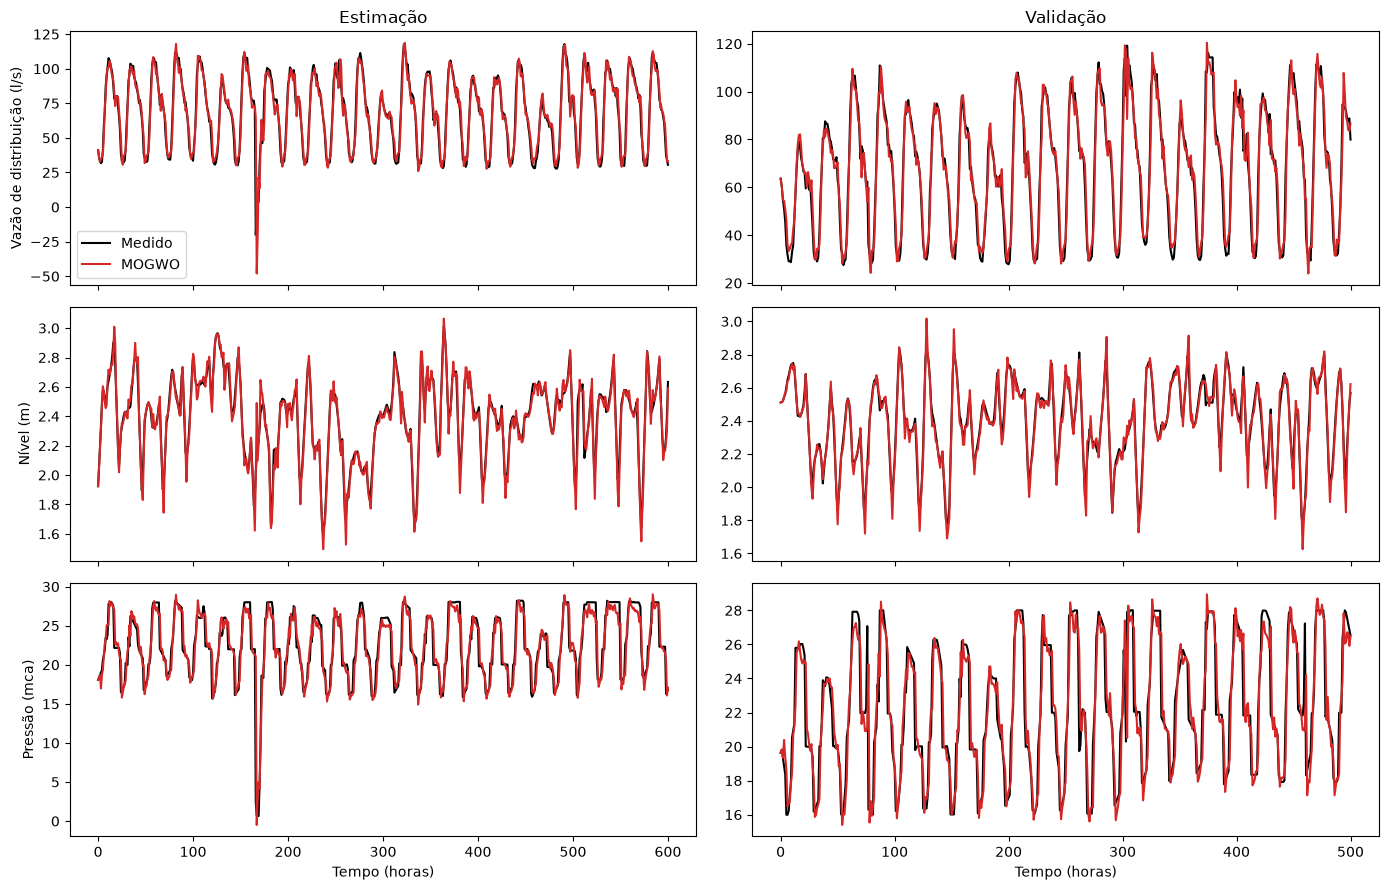

In [10]:
y_pred_est = armax_predict(x_mogwo, U_train, Y_train)[:, :, 0]
y_pred_val = armax_predict(x_mogwo, U_test, Y_test)[:, :, 0]

labels = ["Vazão de distribuição (l/s)", "Nível (m)", "Pressão (mca)"]

fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex="col")
for out in range(3):
    axes[out, 0].plot(Y_train[out], label="Medido", color="black")
    axes[out, 0].plot(y_pred_est[out], label="MOGWO", color="tab:red")
    axes[out, 0].set_ylabel(labels[out])

    axes[out, 1].plot(Y_test[out], label="Medido", color="black")
    axes[out, 1].plot(y_pred_val[out], label="MOGWO", color="tab:red")

axes[0, 0].set_title("Estimação")
axes[0, 1].set_title("Validação")
axes[-1, 0].set_xlabel("Tempo (horas)")
axes[-1, 1].set_xlabel("Tempo (horas)")
axes[0, 0].legend()
fig.tight_layout()

In [11]:
from plotly.subplots import make_subplots

import plotly.graph_objects as go

for out, label in enumerate(labels):
    fig = make_subplots(
        rows=2,
        cols=1,
        shared_xaxes=True,
        subplot_titles=(
            f"Estimação — MSE={mse_est[out, best_idx]:.4f}, "
            f"R²={r2_est[out, best_idx]:.4f}",
            f"Validação — MSE={mse_val[out, best_idx]:.4f}, "
            f"R²={r2_val[out, best_idx]:.4f}",
        ),
        vertical_spacing=0.12,
    )

    fig.add_trace(
        go.Scatter(
            x=np.arange(Y_train.shape[1]),
            y=Y_train[out],
            name="Medido",
            line=dict(color="black", width=1),
            legendgroup="medido",
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=np.arange(Y_train.shape[1]),
            y=y_pred_est[out],
            name="Predito",
            line=dict(color="firebrick", width=1),
            legendgroup="predito",
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=np.arange(Y_test.shape[1]),
            y=Y_test[out],
            name="Medido",
            line=dict(color="black", width=1),
            legendgroup="medido",
            showlegend=False,
        ),
        row=2,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=np.arange(Y_test.shape[1]),
            y=y_pred_val[out],
            name="Predito",
            line=dict(color="royalblue", width=1),
            legendgroup="predito",
            showlegend=False,
        ),
        row=2,
        col=1,
    )

    fig.update_yaxes(title_text=label, row=1, col=1)
    fig.update_yaxes(title_text=label, row=2, col=1)
    fig.update_xaxes(title_text="Tempo (amostras)", row=2, col=1)
    fig.update_layout(
        title_text=label,
        height=700,
        hovermode="x unified",
        template="plotly_white",
    )
    fig.show()


### Comparação com a Tabela 2 do artigo

In [12]:
# "The best model from validation" da Tabela 2, coluna MOGWO
PAPER_MOGWO_BEST = pd.DataFrame(
    {"mse_paper": [33.486, 0.0025, 2.3168], "r2_paper": [0.9478, 0.9526, 0.8364]},
    index=["y1_vazao", "y2_nivel", "y3_pressao"],
)

comparison = PAPER_MOGWO_BEST.copy()
comparison["mse_aqui"] = mse_val[:, best_idx]
comparison["r2_aqui"] = r2_val[:, best_idx]
comparison.round(4)

,mse_paper,r2_paper,mse_aqui,r2_aqui
y1_vazao,33.4860,0.9478,33.5004,0.9477
y2_nivel,0.0025,0.9526,0.0024,0.9540
y3_pressao,2.3168,0.8364,2.3167,0.8364


MSE e R² batem com a Tabela 2 nas 3 saídas. A diferença que sobra em y2
(~0.001 de R²) é compatível com os 3 dígitos dos parâmetros da Tabela 3.

Causa da discrepância anterior (R² de y2 em 0.67): o MATLAB trata as 3
primeiras predições como iguais ao medido e o nosso porte não. Esse
erro nas 3 primeiras amostras pesava mais em y2 por ser de escala
pequena. Ver `docs/changes/2026-09-25-reproduzir-mogwo.md`.